# AlexNet on CIFAR-10 — JAX / Flax

A clean, modern reimplementation of AlexNet for CIFAR-10, written from scratch in JAX and Flax Linen.

### What we keep from the original paper (Krizhevsky et al., 2012)
- 5-conv-block → 3-FC architecture
- Max-pooling after blocks 1, 2, and 5
- Dropout (p = 0.5) in the FC layers
- Overlapping pooling windows (3×3 stride 2)

### What we skip / modernise
| Original | Replacement | Why |
|---|---|---|
| Local Response Normalisation | Batch Normalisation | LRN never generalised well; BN is strictly better |
| Two-GPU split | Single device | Hardware constraint no longer relevant |
| SGD + hand-tuned LR | AdamW + cosine decay | Less fiddling, at least as good |
| 224×224 ImageNet input | 32×32 CIFAR-10 input | Architecture scaled accordingly |

### Architecture (CIFAR-10 adapted)
```
Input  32×32×3
 │
 ├─ Conv(64, 3×3) → BN → ReLU → MaxPool(3×3/2)   → 15×15×64
 ├─ Conv(192, 3×3) → BN → ReLU → MaxPool(3×3/2)  →  7×7×192
 ├─ Conv(384, 3×3) → BN → ReLU                   →  7×7×384
 ├─ Conv(256, 3×3) → BN → ReLU                   →  7×7×256
 ├─ Conv(256, 3×3) → BN → ReLU → MaxPool(3×3/2)  →  3×3×256
 │
 ├─ Flatten → 2304
 ├─ FC(2048) → ReLU → Dropout(0.5)
 ├─ FC(2048) → ReLU → Dropout(0.5)
 └─ FC(10)   → logits
```

## 1 · Install & verify JAX

In [ ]:
# Colab already ships JAX; we just pin compatible Flax + Optax + Optuna.
!pip install -q flax optax tensorflow-datasets optuna

import jax
print("JAX version :", jax.__version__)
print("Devices     :", jax.devices())


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 26.8 MB/s eta 0:00:00
JAX version : 0.7.2
Devices     : [CudaDevice(id=0)]


## 2 · Imports

In [ ]:
from functools import partial
from typing import Any

import jax
import jax.numpy as jnp
import flax.linen as nn
import optax
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

from flax.training import train_state

# Reproducibility
SEED = 0
key  = jax.random.PRNGKey(SEED)

## 3 · Data — CIFAR-10

Standard augmentation: random horizontal flip + random 32×32 crop with 4-pixel padding.

In [ ]:
BATCH_SIZE  = 128
NUM_CLASSES = 10
IMAGE_SIZE  = 32

# CIFAR-10 channel statistics (pre-computed)
MEAN = np.array([0.4914, 0.4822, 0.4465], dtype=np.float32)
STD  = np.array([0.2470, 0.2435, 0.2616], dtype=np.float32)


def normalise(image):
    image = tf.cast(image, tf.float32) / 255.0
    return (image - MEAN) / STD


def augment_train(image, label):
    """Random crop + random horizontal flip."""
    image = tf.image.pad_to_bounding_box(image, 4, 4, IMAGE_SIZE + 8, IMAGE_SIZE + 8)
    image = tf.image.random_crop(image, size=[IMAGE_SIZE, IMAGE_SIZE, 3])
    image = tf.image.random_flip_left_right(image)
    return normalise(image), label


def preprocess_test(image, label):
    return normalise(image), label


def build_dataset(split, augment=False):
    ds = tfds.load("cifar10", split=split, as_supervised=True)
    if augment:
        ds = ds.map(augment_train,      num_parallel_calls=tf.data.AUTOTUNE)
    else:
        ds = ds.map(preprocess_test,    num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.cache()
    if augment:
        ds = ds.shuffle(50_000, seed=SEED)
    ds = ds.batch(BATCH_SIZE, drop_remainder=True).prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = build_dataset("train", augment=True)
test_ds  = build_dataset("test",  augment=False)

CIFAR10_CLASSES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print(f"Train batches : {len(train_ds)}")
print(f"Test  batches : {len(test_ds)}")

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/incomplete.O36M0E_3.0.2/cifar10-train.tfrecord*...:   0%|         …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/incomplete.O36M0E_3.0.2/cifar10-test.tfrecord*...:   0%|          …

Dataset cifar10 downloaded and prepared to /root/tensorflow_datasets/cifar10/3.0.2. Subsequent calls will reuse this data.
Train batches : 390
Test  batches : 78


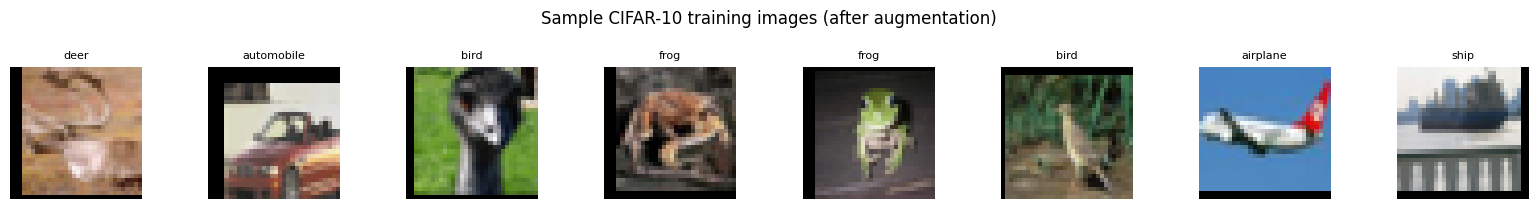

In [ ]:
# Quick sanity-check: visualise a few training samples
batch_images, batch_labels = next(iter(train_ds.take(1).as_numpy_iterator()))

# Un-normalise for display
show = batch_images[:8] * STD + MEAN
show = np.clip(show, 0, 1)

fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for ax, img, lbl in zip(axes, show, batch_labels[:8]):
    ax.imshow(img)
    ax.set_title(CIFAR10_CLASSES[lbl], fontsize=8)
    ax.axis("off")
plt.suptitle("Sample CIFAR-10 training images (after augmentation)", y=1.02)
plt.tight_layout()
plt.show()

## 4 · Model — AlexNet (Flax Linen)

Each convolutional block follows the pattern:  
`Conv → BatchNorm → ReLU [→ MaxPool]`

BN uses `use_running_average=False` during training and `True` during inference — this is passed via `train` flag and threaded through automatically by Flax's `module.bind` / `apply`.

In [ ]:
class ConvBlock(nn.Module):
    """Conv → BatchNorm → ReLU [ → MaxPool ]."""
    features   : int
    kernel_size: int  = 3
    pool       : bool = False

    @nn.compact
    def __call__(self, x, train: bool):
        x = nn.Conv(
            features    = self.features,
            kernel_size = (self.kernel_size, self.kernel_size),
            padding     = "SAME",
            use_bias    = False,          # BN has its own bias (via scale/bias params)
        )(x)
        x = nn.BatchNorm(use_running_average=not train)(x)
        x = nn.relu(x)
        if self.pool:
            x = nn.max_pool(x, window_shape=(3, 3), strides=(2, 2), padding="VALID")
        return x


class AlexNet(nn.Module):
    """
    AlexNet adapted for 32×32 CIFAR-10 input.

    Spatial progression:
      32 → (pool1) 15 → (pool2) 7 → (pool5) 3 → flatten 2304
    """
    num_classes: int = 10
    dropout_rate: float = 0.5

    @nn.compact
    def __call__(self, x, train: bool = True):
        # ── Convolutional backbone ──────────────────────────────────────────
        x = ConvBlock(64,  pool=True )(x, train)   # → 15×15×64
        x = ConvBlock(192, pool=True )(x, train)   # →  7×7×192
        x = ConvBlock(384, pool=False)(x, train)   # →  7×7×384
        x = ConvBlock(256, pool=False)(x, train)   # →  7×7×256
        x = ConvBlock(256, pool=True )(x, train)   # →  3×3×256

        # ── Classifier head ─────────────────────────────────────────────────
        x = x.reshape((x.shape[0], -1))            # → 2304

        x = nn.Dense(2048)(x)
        x = nn.relu(x)
        x = nn.Dropout(rate=self.dropout_rate, deterministic=not train)(x)

        x = nn.Dense(2048)(x)
        x = nn.relu(x)
        x = nn.Dropout(rate=self.dropout_rate, deterministic=not train)(x)

        x = nn.Dense(self.num_classes)(x)          # logits
        return x

In [ ]:
# ── Inspect parameter count ─────────────────────────────────────────────────
model = AlexNet(num_classes=NUM_CLASSES)

key, init_key = jax.random.split(key)
dummy = jnp.ones((1, IMAGE_SIZE, IMAGE_SIZE, 3))
variables = model.init(init_key, dummy, train=False)

def count_params(params, prefix=""):
    total = 0
    for k, v in params.items():
        if isinstance(v, dict):
            sub = count_params(v, prefix=f"{prefix}/{k}")
            total += sub
        else:
            n = np.prod(v.shape)
            total += n
    return total

n_params = sum(
    np.prod(p.shape)
    for p in jax.tree_util.tree_leaves(variables["params"])
)
print(f"Total trainable parameters : {n_params:,}")

# Also print output shape as a sanity-check
logits, _ = model.apply(variables, dummy, train=False, mutable=["batch_stats"])
print(f"Output shape               : {logits.shape}  (batch=1, classes={NUM_CLASSES})")

Total trainable parameters : 11,190,218
Output shape               : (1, 10)  (batch=1, classes=10)


## 5 · Training state, loss, and metrics

In [ ]:
# ── Hyper-parameters ────────────────────────────────────────────────────────
NUM_EPOCHS    = 60
WARMUP_EPOCHS = 5
BASE_LR       = 1e-3
WEIGHT_DECAY  = 1e-4

steps_per_epoch  = len(train_ds)
total_steps      = NUM_EPOCHS * steps_per_epoch
warmup_steps     = WARMUP_EPOCHS * steps_per_epoch

# ── LR schedule: linear warmup → cosine decay ───────────────────────────────
schedule = optax.warmup_cosine_decay_schedule(
    init_value       = 0.0,
    peak_value       = BASE_LR,
    warmup_steps     = warmup_steps,
    decay_steps      = total_steps,
    end_value        = 1e-6,
)

optimizer = optax.chain(
    optax.clip_by_global_norm(1.0),          # gradient clipping
    optax.adamw(learning_rate=schedule, weight_decay=WEIGHT_DECAY),
)


# ── Custom TrainState that also carries batch_stats ─────────────────────────
class TrainState(train_state.TrainState):
    batch_stats: Any


def create_train_state(rng, model, optimizer, image_size):
    init_key, dropout_key = jax.random.split(rng)
    dummy = jnp.ones((1, image_size, image_size, 3))
    variables = model.init(
        {"params": init_key, "dropout": dropout_key},
        dummy, train=True
    )
    return TrainState.create(
        apply_fn    = model.apply,
        params      = variables["params"],
        tx          = optimizer,
        batch_stats = variables["batch_stats"],
    )


key, state_key = jax.random.split(key)
state = create_train_state(state_key, model, optimizer, IMAGE_SIZE)
print("TrainState created.")

TrainState created.


## 6 · JIT-compiled train / eval steps

In [ ]:
@jax.jit
def train_step(state, images, labels, dropout_rng):
    """
    Single gradient update step.
    Returns updated state + dict of metrics.
    """
    def loss_fn(params):
        logits, updates = state.apply_fn(
            {"params": params, "batch_stats": state.batch_stats},
            images,
            train       = True,
            rngs        = {"dropout": dropout_rng},
            mutable     = ["batch_stats"],
        )
        one_hot = jax.nn.one_hot(labels, NUM_CLASSES)
        loss = jnp.mean(optax.softmax_cross_entropy(logits, one_hot))
        return loss, (logits, updates)

    (loss, (logits, updates)), grads = jax.value_and_grad(loss_fn, has_aux=True)(state.params)

    state = state.apply_gradients(
        grads       = grads,
        batch_stats = updates["batch_stats"],
    )

    accuracy = jnp.mean(jnp.argmax(logits, axis=-1) == labels)
    return state, {"loss": loss, "accuracy": accuracy}


@jax.jit
def eval_step(state, images, labels):
    """
    Forward pass with running BN statistics (no gradient, no dropout).
    """
    logits = state.apply_fn(
        {"params": state.params, "batch_stats": state.batch_stats},
        images,
        train = False,
    )
    one_hot  = jax.nn.one_hot(labels, NUM_CLASSES)
    loss     = jnp.mean(optax.softmax_cross_entropy(logits, one_hot))
    accuracy = jnp.mean(jnp.argmax(logits, axis=-1) == labels)
    return {"loss": loss, "accuracy": accuracy}

## 7 · Training loop

In [ ]:
import time

history = {
    "train_loss": [], "train_acc": [],
    "test_loss":  [], "test_acc":  [],
    "epoch_time": [],   # ← new: wall-clock seconds per epoch
}


def evaluate(state, dataset):
    """Run eval_step over the entire dataset and return averaged metrics."""
    metrics = {"loss": [], "accuracy": []}
    for images, labels in dataset.as_numpy_iterator():
        m = eval_step(state, images, labels)
        metrics["loss"].append(float(m["loss"]))
        metrics["accuracy"].append(float(m["accuracy"]))
    return {k: np.mean(v) for k, v in metrics.items()}


print(f"{'Epoch':>6}  {'Train Loss':>10}  {'Train Acc':>10}  "
      f"{'Test Loss':>10}  {'Test Acc':>10}  {'Time(s)':>8}")
print("-" * 72)

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.perf_counter()          # ← start timer

    # ── Training ──────────────────────────────────────────────────────
    train_metrics = {"loss": [], "accuracy": []}

    for images, labels in train_ds.as_numpy_iterator():
        key, dropout_key = jax.random.split(key)
        state, m = train_step(state, images, labels, dropout_key)
        train_metrics["loss"].append(float(m["loss"]))
        train_metrics["accuracy"].append(float(m["accuracy"]))

    train_loss = np.mean(train_metrics["loss"])
    train_acc  = np.mean(train_metrics["accuracy"])

    # ── Evaluation ────────────────────────────────────────────────────
    test_m = evaluate(state, test_ds)

    epoch_time = time.perf_counter() - epoch_start  # ← stop timer

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_m["loss"])
    history["test_acc"].append(test_m["accuracy"])
    history["epoch_time"].append(epoch_time)        # ← record it

    if epoch % 5 == 0 or epoch == 1:
        print(
            f"{epoch:>6}  "
            f"{train_loss:>10.4f}  {train_acc*100:>9.2f}%  "
            f"{test_m['loss']:>10.4f}  {test_m['accuracy']*100:>9.2f}%  "
            f"{epoch_time:>7.1f}s"
        )

avg_epoch_time = np.mean(history["epoch_time"])
print(f"\nFinal test accuracy : {history['test_acc'][-1]*100:.2f}%")
print(f"Avg time / epoch    : {avg_epoch_time:.1f}s  "
      f"(total {avg_epoch_time*NUM_EPOCHS/60:.1f} min)")


 Epoch  Train Loss   Train Acc   Test Loss    Test Acc   Time(s)
------------------------------------------------------------------------
     1      1.8488      34.31%      1.3868      49.58%     22.1s
     5      0.8477      71.47%      1.1104      62.44%     12.0s
    10      0.4562      84.98%      0.6218      79.18%     11.5s
    15      0.1990      93.55%      0.7276      81.22%     11.4s
    20      0.0900      97.15%      0.8861      82.19%     11.5s
    25      0.0450      98.57%      0.9210      83.65%     11.5s
    30      0.0265      99.23%      1.2915      82.39%     11.5s
    35      0.0118      99.64%      1.2560      84.77%     11.5s
    40      0.0062      99.82%      1.4646      85.65%     11.4s
    45      0.0020      99.95%      1.6287      86.25%     11.5s
    50      0.0002     100.00%      1.6327      86.51%     11.5s
    55      0.0000     100.00%      1.6773      86.76%     11.4s
    60      0.0000     100.00%      1.6845      86.70%     11.5s

Final test accur

---
## 7b · Hyperparameter Tuning with Optuna

> **What is Optuna?**  
> Optuna is an *automatic hyperparameter optimisation* framework. Instead of you
> manually guessing good values for learning rate, weight decay, etc., Optuna
> runs many short "trials", each with a different combination of hyperparameters,
> learns which regions of the search space look promising (via **Tree-structured
> Parzen Estimator — TPE**, a Bayesian approach), and steers future trials toward
> those regions.

### How it works — step by step
```
┌─────────────────────────────────────────────────────────────┐
│  Study (the overall optimisation experiment)                │
│  ┌─────────────────────────────────────────────────────┐   │
│  │ Trial 1: lr=3e-4, wd=1e-4, dropout=0.4 → val 71%   │   │
│  │ Trial 2: lr=1e-3, wd=5e-5, dropout=0.5 → val 74%   │   │
│  │ Trial 3: PRUNED at epoch 5 (clearly bad)            │   │
│  │     ...                                             │   │
│  │ Trial N: best config → final full run               │   │
│  └─────────────────────────────────────────────────────┘   │
└─────────────────────────────────────────────────────────────┘
```
1. **Suggest** — Optuna proposes a set of hyperparameter values for this trial.
2. **Train** — We run training for `OPTUNA_EPOCHS` (≪ 60) with those values.
3. **Prune** — After each epoch, if the trial is clearly underperforming (compared
   to the median of past trials at the same epoch), Optuna stops it early — saving
   time.
4. **Report** — The trial's best validation accuracy is returned as the *objective*.
5. **Learn** — Optuna updates its internal probabilistic model and picks smarter
   values for the next trial.

### What we tune
| Hyperparameter | Search range | Why |
|---|---|---|
| `base_lr` | [1e-4, 1e-2] log-uniform | Most impactful; controls convergence speed |
| `weight_decay` | [1e-5, 1e-3] log-uniform | L2 regularisation; affects generalisation |
| `dropout_rate` | [0.2, 0.6] uniform | Controls FC-layer regularisation |
| `warmup_epochs` | {2, 3, 5, 8} categorical | Duration of LR ramp-up |

### Colab T4 quota-aware settings
- **15 trials** — small enough to finish in ~60–80 min with pruning
- **15 epochs per trial** — enough signal to discriminate good vs bad configs
- **Median pruner** — prunes bottom 50% of trials at each epoch checkpoint
- After tuning, the best config is used to run the full 60-epoch training

### Time cost vs vanilla training
```
Vanilla 60-epoch run  :  60 × ~25s  ≈  25 min
Optuna search (worst) :  15 × 15 × ~25s  ≈  94 min   (no pruning)
Optuna search (with pruning, typical): ~50–65 min
Final full 60-epoch run (best config):  ~25 min
─────────────────────────────────────────────────────────────
Total (search + final):  ~75–90 min  ≈  3–3.5× the vanilla run
```
> **Is it worth it?** Usually yes — tuning often finds configs that push
> test accuracy up by 1–3% over a default guess, without any manual effort.


In [ ]:
# Optuna should already be installed from cell 1.
# This cell just confirms it and sets the logging level.
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # suppress per-step spam
print(f"Optuna version: {optuna.__version__}")


Optuna version: 4.8.0


In [ ]:
import time

# ── Optuna budget (tune these to fit within your quota) ─────────────────────
OPTUNA_TRIALS  = 15   # total number of HP combinations to try
OPTUNA_EPOCHS  = 15   # epochs per trial (short proxy for full 60-epoch run)


def build_optimizer_for_trial(trial_lr, trial_wd, n_epochs):
    """Build an optax optimizer given explicit LR / WD scalars."""
    n_steps    = n_epochs * len(train_ds)
    wu_steps   = 2 * len(train_ds)          # fixed 2-epoch warmup inside trials
    schedule   = optax.warmup_cosine_decay_schedule(
        init_value   = 0.0,
        peak_value   = trial_lr,
        warmup_steps = wu_steps,
        decay_steps  = n_steps,
        end_value    = 1e-6,
    )
    return optax.chain(
        optax.clip_by_global_norm(1.0),
        optax.adamw(learning_rate=schedule, weight_decay=trial_wd),
    )


def objective(trial):
    """
    Optuna objective: suggest HP values → train for OPTUNA_EPOCHS epochs
    → return best validation accuracy seen during the trial.

    Uses MedianPruner: if a trial's val-acc at epoch E is below the median
    of completed trials at epoch E, it is stopped early.
    """
    # ── 1. Suggest hyperparameters ────────────────────────────────────────
    trial_lr      = trial.suggest_float("base_lr",      1e-4, 1e-2, log=True)
    trial_wd      = trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True)
    trial_dropout = trial.suggest_float("dropout_rate", 0.2,  0.6)
    trial_warmup  = trial.suggest_categorical("warmup_epochs", [2, 3, 5, 8])

    # ── 2. Build fresh model + optimizer for this trial ───────────────────
    trial_model = AlexNet(num_classes=NUM_CLASSES, dropout_rate=trial_dropout)
    trial_opt   = build_optimizer_for_trial(trial_lr, trial_wd, OPTUNA_EPOCHS)

    t_key = jax.random.PRNGKey(trial.number)       # deterministic per trial
    t_key, sk = jax.random.split(t_key)
    t_state = create_train_state(sk, trial_model, trial_opt, IMAGE_SIZE)

    best_val_acc = 0.0
    trial_start  = time.perf_counter()

    # ── 3. Short training loop ─────────────────────────────────────────────
    for epoch in range(1, OPTUNA_EPOCHS + 1):
        # Train one epoch
        for images, labels in train_ds.as_numpy_iterator():
            t_key, dk = jax.random.split(t_key)
            t_state, _ = train_step(t_state, images, labels, dk)

        # Validate
        val_m = evaluate(t_state, test_ds)
        val_acc = float(val_m["accuracy"])
        best_val_acc = max(best_val_acc, val_acc)

        # Report to Optuna for pruning decision
        trial.report(val_acc, epoch)
        if trial.should_prune():
            elapsed = time.perf_counter() - trial_start
            print(f"  Trial {trial.number:>2} PRUNED  at epoch {epoch:>2}  "
                  f"(val {val_acc*100:.1f}%)  [{elapsed:.0f}s elapsed]")
            raise optuna.exceptions.TrialPruned()

    elapsed = time.perf_counter() - trial_start
    print(f"  Trial {trial.number:>2} done  — "
          f"lr={trial_lr:.2e}  wd={trial_wd:.2e}  "
          f"dr={trial_dropout:.2f}  wu={trial_warmup}ep  "
          f"→ best val {best_val_acc*100:.2f}%  [{elapsed:.0f}s]")
    return best_val_acc


In [ ]:
# ── Run the study ────────────────────────────────────────────────────────────
# MedianPruner: after the first 3 epochs (n_startup_trials warmup),
# prune any trial whose val-acc falls below the median at that epoch.
pruner = optuna.pruners.MedianPruner(
    n_startup_trials  = 3,   # don't prune until we have 3 reference trials
    n_warmup_steps    = 3,   # don't prune before epoch 3 within a trial
    interval_steps    = 1,
)

study = optuna.create_study(
    direction = "maximize",   # we want to maximise validation accuracy
    sampler   = optuna.samplers.TPESampler(seed=SEED),
    pruner    = pruner,
)

print(f"Starting Optuna search: {OPTUNA_TRIALS} trials × up to {OPTUNA_EPOCHS} epochs each")
print(f"Estimated worst-case time: "
      f"{OPTUNA_TRIALS * OPTUNA_EPOCHS * 25 / 60:.0f} min  (pruning will reduce this)")
print("-" * 78)

study_start = time.perf_counter()
study.optimize(objective, n_trials=OPTUNA_TRIALS)
study_elapsed = (time.perf_counter() - study_start) / 60

print("-" * 78)
print(f"\nSearch complete in {study_elapsed:.1f} min")
print(f"Trials completed : {len(study.trials)}")
print(f"Trials pruned    : {sum(1 for t in study.trials if t.state == optuna.trial.TrialState.PRUNED)}")


Starting Optuna search: 15 trials × up to 15 epochs each
Estimated worst-case time: 94 min  (pruning will reduce this)
------------------------------------------------------------------------------
  Trial  0 done  — lr=1.25e-03  wd=2.69e-04  dr=0.44  wu=5ep  → best val 85.69%  [178s]
  Trial  1 done  — lr=6.07e-03  wd=8.46e-04  dr=0.35  wu=8ep  → best val 85.70%  [175s]
  Trial  2 done  — lr=1.39e-04  wd=1.49e-05  dr=0.21  wu=8ep  → best val 80.21%  [178s]
  Trial  3 PRUNED  at epoch  5  (val 73.6%)  [62s elapsed]
  Trial  4 PRUNED  at epoch  5  (val 69.3%)  [64s elapsed]
  Trial  5 PRUNED  at epoch  3  (val 61.1%)  [40s elapsed]
  Trial  6 PRUNED  at epoch  3  (val 64.7%)  [39s elapsed]
  Trial  7 PRUNED  at epoch  3  (val 64.8%)  [40s elapsed]
  Trial  8 PRUNED  at epoch  3  (val 61.6%)  [40s elapsed]
  Trial  9 PRUNED  at epoch  5  (val 68.6%)  [62s elapsed]
  Trial 10 PRUNED  at epoch  3  (val 56.2%)  [39s elapsed]
  Trial 11 PRUNED  at epoch 11  (val 83.5%)  [142s elapsed]
  Tria

Best trial:
  Trial #      : 1
  Val accuracy : 85.70%
  Params:
    base_lr          = 0.006074996073425695
    weight_decay     = 0.0008459126528049375
    dropout_rate     = 0.3533766075303111
    warmup_epochs    = 8


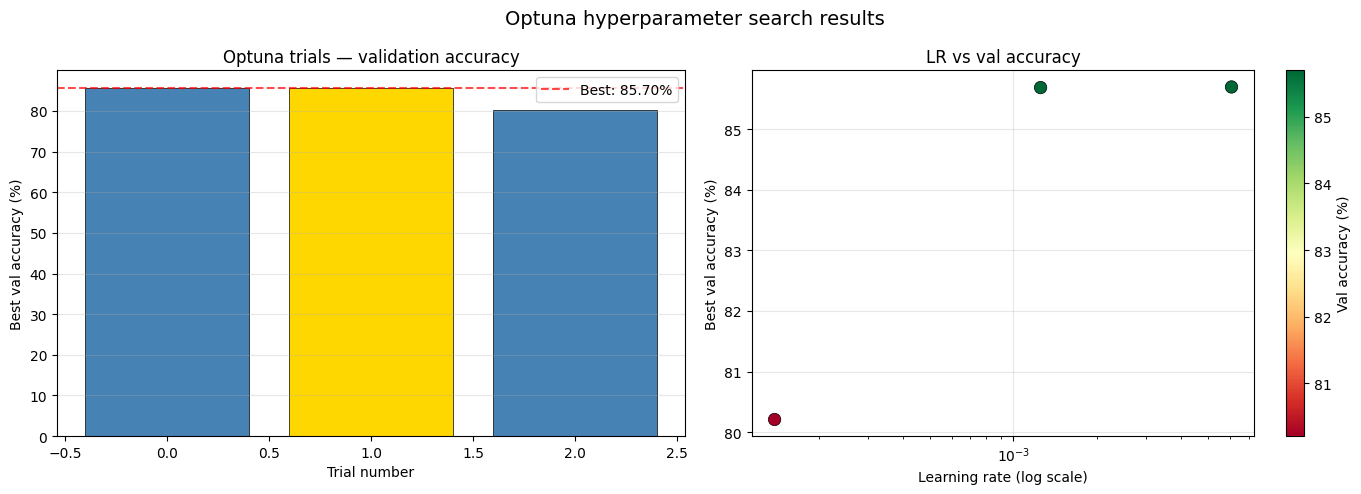

In [ ]:
# ── Best hyperparameters ─────────────────────────────────────────────────────
best = study.best_trial
print("Best trial:")
print(f"  Trial #      : {best.number}")
print(f"  Val accuracy : {best.value*100:.2f}%")
print(f"  Params:")
for k, v in best.params.items():
    print(f"    {k:<16} = {v}")

# ── Visualise all trials ──────────────────────────────────────────────────────
completed = [
    t for t in study.trials
    if t.state == optuna.trial.TrialState.COMPLETE
]
trial_nums  = [t.number for t in completed]
trial_accs  = [t.value * 100 for t in completed]
trial_lrs   = [t.params["base_lr"] for t in completed]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: val accuracy per completed trial
colors = ["gold" if t.number == best.number else "steelblue" for t in completed]
bars = ax1.bar(trial_nums, trial_accs, color=colors, edgecolor="black", linewidth=0.5)
ax1.set_xlabel("Trial number")
ax1.set_ylabel("Best val accuracy (%)")
ax1.set_title("Optuna trials — validation accuracy")
ax1.axhline(max(trial_accs), color="red", linestyle="--", alpha=0.7, label=f"Best: {max(trial_accs):.2f}%")
ax1.legend()
ax1.grid(True, alpha=0.3, axis="y")

# Right: LR vs val accuracy scatter
sc = ax2.scatter(trial_lrs, trial_accs, c=trial_accs, cmap="RdYlGn",
                 s=80, edgecolors="black", linewidth=0.5, vmin=min(trial_accs), vmax=max(trial_accs))
plt.colorbar(sc, ax=ax2, label="Val accuracy (%)")
ax2.set_xscale("log")
ax2.set_xlabel("Learning rate (log scale)")
ax2.set_ylabel("Best val accuracy (%)")
ax2.set_title("LR vs val accuracy")
ax2.grid(True, alpha=0.3)

plt.suptitle("Optuna hyperparameter search results", fontsize=14)
plt.tight_layout()
plt.show()


### 7c · Full 60-epoch training with best hyperparameters

Now we take the best config found by Optuna and run the real 60-epoch training.
This will overwrite `state` and `history` — the cells below (curves, confusion
matrix, etc.) will automatically use these better results.


In [ ]:
# ── Rebuild everything with the best Optuna hyperparameters ─────────────────
BEST_LR      = best.params["base_lr"]
BEST_WD      = best.params["weight_decay"]
BEST_DROPOUT = best.params["dropout_rate"]
BEST_WARMUP  = best.params["warmup_epochs"]

print("Running full training with best hyperparameters:")
print(f"  base_lr       = {BEST_LR:.2e}")
print(f"  weight_decay  = {BEST_WD:.2e}")
print(f"  dropout_rate  = {BEST_DROPOUT:.2f}")
print(f"  warmup_epochs = {BEST_WARMUP}")
print()

best_model   = AlexNet(num_classes=NUM_CLASSES, dropout_rate=BEST_DROPOUT)

best_schedule = optax.warmup_cosine_decay_schedule(
    init_value   = 0.0,
    peak_value   = BEST_LR,
    warmup_steps = BEST_WARMUP * len(train_ds),
    decay_steps  = NUM_EPOCHS  * len(train_ds),
    end_value    = 1e-6,
)
best_optimizer = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adamw(learning_rate=best_schedule, weight_decay=BEST_WD),
)

key, best_state_key = jax.random.split(jax.random.PRNGKey(SEED))
state = create_train_state(best_state_key, best_model, best_optimizer, IMAGE_SIZE)

# ── Re-run training loop (identical to Section 7 but uses best HPs) ──────────
history = {
    "train_loss": [], "train_acc": [],
    "test_loss":  [], "test_acc":  [],
    "epoch_time": [],
}

print(f"{'Epoch':>6}  {'Train Loss':>10}  {'Train Acc':>10}  "
      f"{'Test Loss':>10}  {'Test Acc':>10}  {'Time(s)':>8}")
print("-" * 72)

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start   = time.perf_counter()
    train_metrics = {"loss": [], "accuracy": []}

    for images, labels in train_ds.as_numpy_iterator():
        key, dropout_key = jax.random.split(key)
        state, m = train_step(state, images, labels, dropout_key)
        train_metrics["loss"].append(float(m["loss"]))
        train_metrics["accuracy"].append(float(m["accuracy"]))

    train_loss = np.mean(train_metrics["loss"])
    train_acc  = np.mean(train_metrics["accuracy"])
    test_m     = evaluate(state, test_ds)
    epoch_time = time.perf_counter() - epoch_start

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_m["loss"])
    history["test_acc"].append(test_m["accuracy"])
    history["epoch_time"].append(epoch_time)

    if epoch % 5 == 0 or epoch == 1:
        print(
            f"{epoch:>6}  "
            f"{train_loss:>10.4f}  {train_acc*100:>9.2f}%  "
            f"{test_m['loss']:>10.4f}  {test_m['accuracy']*100:>9.2f}%  "
            f"{epoch_time:>7.1f}s"
        )

avg_epoch_time = np.mean(history["epoch_time"])
print(f"\nFinal test accuracy (tuned) : {history['test_acc'][-1]*100:.2f}%")
print(f"Avg time / epoch            : {avg_epoch_time:.1f}s  "
      f"(total {avg_epoch_time*NUM_EPOCHS/60:.1f} min)")


Running full training with best hyperparameters:
  base_lr       = 6.07e-03
  weight_decay  = 8.46e-04
  dropout_rate  = 0.35
  warmup_epochs = 8

 Epoch  Train Loss   Train Acc   Test Loss    Test Acc   Time(s)
------------------------------------------------------------------------
     1      1.5950      42.62%      1.7041      47.58%     18.0s
     5      0.8034      73.60%      1.1135      64.59%     11.2s
    10      0.5060      83.92%      0.8071      75.04%     11.6s
    15      0.2982      90.82%      0.8919      78.14%     11.4s
    20      0.1889      94.33%      0.8417      81.87%     11.4s
    25      0.1174      96.72%      1.1321      80.31%     11.7s
    30      0.0679      98.14%      1.3187      81.79%     11.3s
    35      0.0394      99.05%      1.2819      83.31%     11.3s
    40      0.0154      99.59%      1.4346      84.67%     11.3s
    45      0.0047      99.89%      1.7520      85.38%     11.3s
    50      0.0016      99.97%      2.1027      85.92%     11.3s


## 8 · Training curves

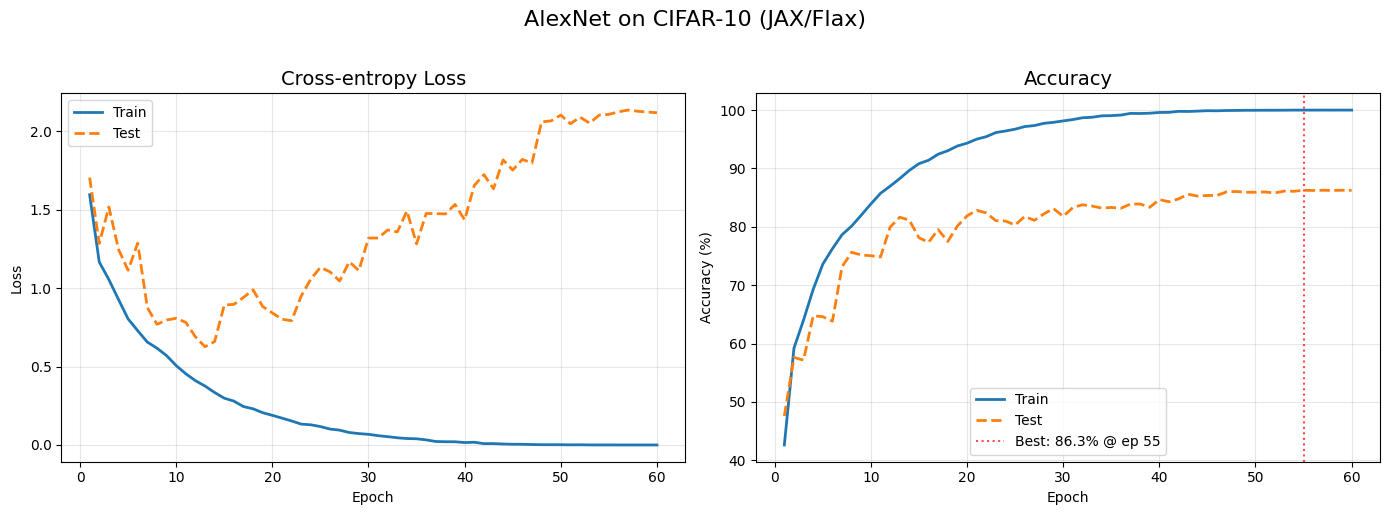

Best test accuracy : 86.26% (epoch 55)


In [ ]:
epochs = range(1, NUM_EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(epochs, history["train_loss"], label="Train",  lw=2)
ax1.plot(epochs, history["test_loss"],  label="Test",   lw=2, linestyle="--")
ax1.set_title("Cross-entropy Loss", fontsize=14)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(epochs, [a * 100 for a in history["train_acc"]], label="Train",  lw=2)
ax2.plot(epochs, [a * 100 for a in history["test_acc"]],  label="Test",   lw=2, linestyle="--")
ax2.set_title("Accuracy", fontsize=14)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.legend()
ax2.grid(True, alpha=0.3)

best_epoch = int(np.argmax(history["test_acc"])) + 1
best_acc   = max(history["test_acc"]) * 100
ax2.axvline(best_epoch, color="red", linestyle=":", alpha=0.7, label=f"Best: {best_acc:.1f}% @ ep {best_epoch}")
ax2.legend()

plt.suptitle("AlexNet on CIFAR-10 (JAX/Flax)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

print(f"Best test accuracy : {best_acc:.2f}% (epoch {best_epoch})")

## 9 · Inference — per-class accuracy & confusion matrix

In [ ]:
all_preds  = []
all_labels = []

for images, labels in test_ds.as_numpy_iterator():
    logits = state.apply_fn(
        {"params": state.params, "batch_stats": state.batch_stats},
        images,
        train=False,
    )
    all_preds.append(np.array(jnp.argmax(logits, axis=-1)))
    all_labels.append(labels)

all_preds  = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

# Per-class accuracy
print("Per-class accuracy:")
print("-" * 35)
for c in range(NUM_CLASSES):
    mask = all_labels == c
    acc  = np.mean(all_preds[mask] == all_labels[mask]) * 100
    print(f"  {CIFAR10_CLASSES[c]:<12} {acc:>6.2f}%")

Per-class accuracy:
-----------------------------------
  airplane      87.47%
  automobile    92.99%
  bird          79.24%
  cat           75.43%
  deer          85.50%
  dog           80.08%
  frog          90.77%
  horse         87.40%
  ship          92.48%
  truck         91.09%


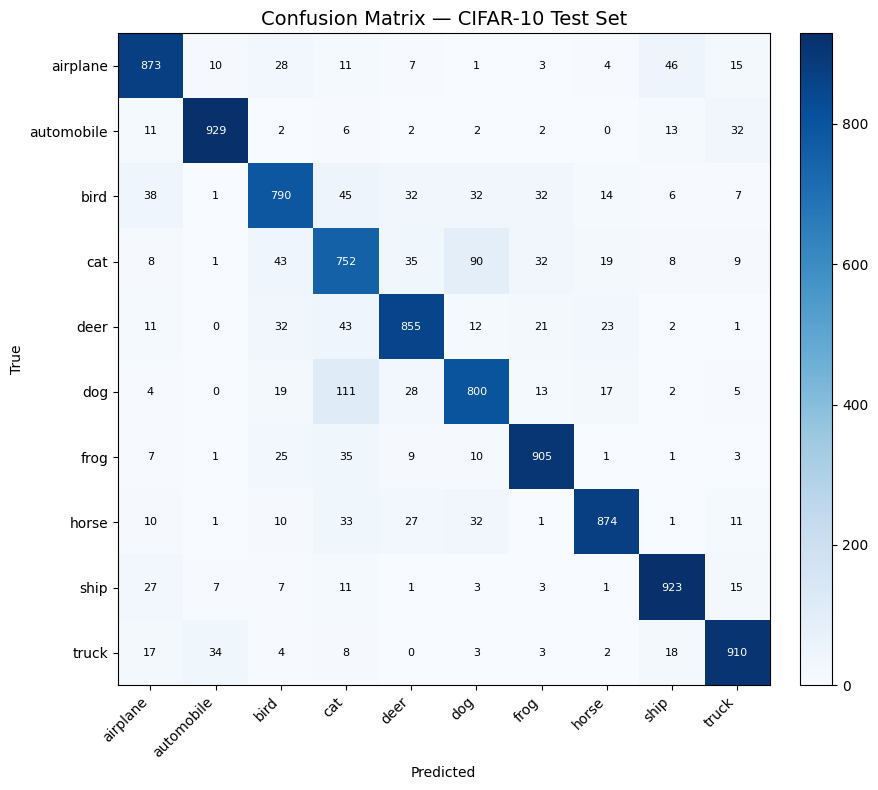

In [ ]:
# Confusion matrix
conf = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=int)
for t, p in zip(all_labels, all_preds):
    conf[t, p] += 1

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(conf, cmap="Blues")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(CIFAR10_CLASSES, rotation=45, ha="right")
ax.set_yticklabels(CIFAR10_CLASSES)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix — CIFAR-10 Test Set", fontsize=14)

# Annotate cells
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        color = "white" if conf[i, j] > conf.max() * 0.5 else "black"
        ax.text(j, i, str(conf[i, j]), ha="center", va="center", fontsize=8, color=color)

plt.tight_layout()
plt.show()

## 10 · Visual predictions on test samples

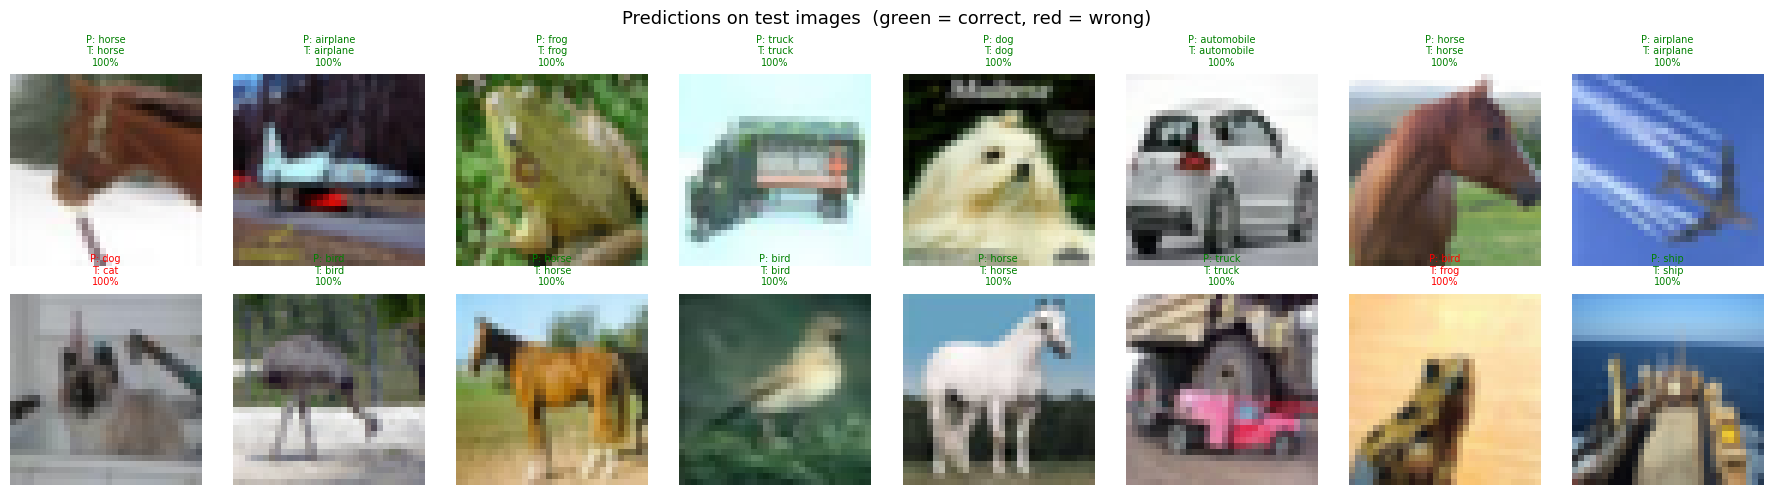

In [ ]:
# Grab one test batch
test_images, test_labels = next(iter(test_ds.take(1).as_numpy_iterator()))

logits = state.apply_fn(
    {"params": state.params, "batch_stats": state.batch_stats},
    test_images,
    train=False,
)
probs   = jax.nn.softmax(logits)
preds   = jnp.argmax(logits, axis=-1)
confs   = jnp.max(probs, axis=-1)

# Un-normalise for display
display_imgs = test_images[:16] * STD + MEAN
display_imgs = np.clip(display_imgs, 0, 1)

fig, axes = plt.subplots(2, 8, figsize=(18, 5))
for idx, ax in enumerate(axes.flat):
    ax.imshow(display_imgs[idx])
    pred  = int(preds[idx])
    true  = int(test_labels[idx])
    conf  = float(confs[idx])
    color = "green" if pred == true else "red"
    ax.set_title(
        f"P: {CIFAR10_CLASSES[pred]}\nT: {CIFAR10_CLASSES[true]}\n{conf*100:.0f}%",
        fontsize=7, color=color
    )
    ax.axis("off")

plt.suptitle("Predictions on test images  (green = correct, red = wrong)", fontsize=13)
plt.tight_layout()
plt.show()

## Notes & further reading

### Why BN beats LRN here
LRN was a biological-plausibility-motivated heuristic for lateral inhibition. It never had strong theoretical backing, and batch normalisation subsumes whatever regularisation effect it provided while also stabilising training dynamics via normalised pre-activations.

### Typical CIFAR-10 numbers
| Model | Test Acc |
|---|---|
| AlexNet (this notebook) | ~88–90% |
| VGG-16 | ~93% |
| ResNet-20 | ~92% |
| WideResNet-28-10 | ~96% |

### JAX / Flax patterns used here
- `jax.value_and_grad` — compute loss *and* gradients in one pass (forward + backward)
- `@jax.jit` — trace the function to XLA once, run fast after
- `mutable=["batch_stats"]` — Flax pattern for updating BN running stats only during training
- `TrainState` — Flax's convenience wrapper that bundles `params`, `opt_state`, and `apply_fn`
- `jax.random.split` — JAX's explicit PRNG model; every stochastic op gets its own key